# TICA and MSM Pipeline for MD Simulations Data

In [1]:
##### This Jupyter notebook has calculates tICA and applies MSM and Transition Paths. 

##### Author: SB (latest update: Aug 9, 2024)
##### Updated: MR (latest update: Mar 25, 2025) 

In [1]:
##### This pipeline was designed to be used after the Collective Variable Analysis by DS (on Frontier/Andes)
##### as the input CVs were structured to match that specific file format. 
##### However, it can be modified to accommodate other input data formats as needed.
##### 
##### (Private repository available to the GK/ HW labs)
##### Available at: https://github.com/weinsteinlab/collective_variable_parallel_rhea

# Step 0: Imports 

In [ ]:
##### Please ensure you have properly set up the conda environment with all libraries. (MSM Builder and MD traj)

In [16]:
import warnings
warnings.filterwarnings("ignore")

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import mdtraj as md
import matplotlib
from sklearn.cluster import KMeans
import pandas as pd
from mdtraj.formats import PDBTrajectoryFile
import os
#import h5py
import mdtraj.io as io
matplotlib.use('Agg')
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.cm as cm

import msmbuilder
import msmbuilder.decomposition.tica as ti
from msmbuilder.cluster import KMeans, KCenters
from msmbuilder.msm import ContinuousTimeMSM, MarkovStateModel
from msmbuilder.msm import implied_timescales

from mpl_toolkits import mplot3d

# Step 1: Load CV files 

In [ ]:
### This is the step that user's might want to modify to fit their input data. 
### Make sure have same number for each, if not will give 'Shape mismatch' and need to re-run tcl. 

### System 1: WildType (NaCl) 

In [3]:
parms = ("CV0001", "CV0002", "CV0003", "CV0004", "CV0005", "CV0006", "CV0007", "CV0008", "CV0009", "CV0010")
wt_dataset = []
for i in range(456): # Number of trajectories you have 
    # Load the reference file without replacing invalid data
    ref = np.genfromtxt(
        "/lustre/orion/bip109/scratch/margaridarosa/MFSD2A_WT_Frontier_OpenMM_Ensemble/collective_variables_for_tica_ions_lpc_and_protein/swarm0000_CVs/swarm0000_traj%04d_CVs/swarm0000_traj%04d_CV0001.dat" % (i, i),
        invalid_raise=False  # No filling of invalid entries
    )
    
    # Create an array for storing data, with size (len(ref) - 1) x len(parms)
    if len(ref) > 1:
        d = np.zeros((len(ref) - 1, len(parms)))  # Proceed only if reference has enough data
    else:
        print("Skipping traj {0}: reference data too short".format(i))
        continue
    
    for p in range(len(parms)):
        # Load each parameter file without replacing invalid data
        data = np.genfromtxt(
            "/lustre/orion/bip109/scratch/margaridarosa/MFSD2A_WT_Frontier_OpenMM_Ensemble/collective_variables_for_tica_ions_lpc_and_protein/swarm0000_CVs/swarm0000_traj%04d_CVs/swarm0000_traj%04d_%s.dat" % (i, i, parms[p]),
            invalid_raise=False  # No filling of invalid entries
        )
        
        # Check if the length of 'data' matches 'ref - 1'
        if len(data[1:]) != len(ref) - 1:
            print("Shape mismatch in traj {0}, param {1}: data shape {2}, ref shape {3}".format(i, parms[p], len(data[1:]), len(ref) - 1))
            # Here you can handle the mismatch by either skipping this trajectory/parameter or padding/truncating the data
            continue
        else:
            d[:, p] = data[1:(len(ref))]  # Exclude the first row as in the original code
    
    wt_dataset.append(d)

# You can now convert 'wt_dataset' into a dataframe if needed

### System 2: LiCl 

In [4]:
parms = ("CV0001", "CV0002", "CV0003", "CV0004", "CV0005", "CV0006", "CV0007", "CV0008", "CV0009", "CV0010")
Li_dataset = []
for i in range(456):
    # Load the reference file without replacing invalid data
    ref = np.genfromtxt(
        "/lustre/orion/bip109/scratch/margaridarosa/MFSD2A_Li_Frontier_OpenMM_Ensemble/collective_variables_for_tica_ions_lpc/swarm0000_CVs/swarm0000_traj%04d_CVs/swarm0000_traj%04d_CV0001.dat" % (i, i),
        invalid_raise=False  # No filling of invalid entries
    )
    
    # Create an array for storing data, with size (len(ref) - 1) x len(parms)
    if len(ref) > 1:
        d = np.zeros((len(ref) - 1, len(parms)))  # Proceed only if reference has enough data
    else:
        print("Skipping traj {0}: reference data too short".format(i))
        continue
    
    for p in range(len(parms)):
        # Load each parameter file without replacing invalid data
        data = np.genfromtxt(
            "/lustre/orion/bip109/scratch/margaridarosa/MFSD2A_Li_Frontier_OpenMM_Ensemble/collective_variables_for_tica_ions_lpc/swarm0000_CVs/swarm0000_traj%04d_CVs/swarm0000_traj%04d_%s.dat" % (i, i, parms[p]),
            invalid_raise=False  # No filling of invalid entries
        )
        
        # Check if the length of 'data' matches 'ref - 1'
        if len(data[1:]) != len(ref) - 1:
            print("Shape mismatch in traj {0}, param {1}: data shape {2}, ref shape {3}".format(i, parms[p], len(data[1:]), len(ref) - 1))
            # Here you can handle the mismatch by either skipping this trajectory/parameter or padding/truncating the data
            continue
        else:
            d[:, p] = data[1:(len(ref))]  # Exclude the first row as in the original code
    
    Li_dataset.append(d)

In [6]:
first_dataset= wt_dataset+ Li_dataset 

In [132]:
# Step 1.1: Save CV files into npy and then can just load 
# format= list where columns are Cvs and rows are frames and you have a dataframe for each trajectory 
# need this format! 

In [133]:
np.save('mfsd2a_combined_WT_Li_CV.npy',first_dataset)
first_dataset=np.load('mfsd2a_combined_WT_Li_CV.npy')

In [20]:
first_dataset=np.load('mfsd2a_combined_WT_Li_CV.npy')

In [5]:
# Adding in input frames

In [4]:
cvs=['CV1','CV2','CV3','CV4','CV5','CV6','CV7','CV8','CV9','CV10']
wt_df=np.zeros((57,10))
for cv in range(len(cvs)):
    wt_input= np.loadtxt("/lustre/orion/bip109/scratch/margaridarosa/analyses_for_MFSD2A_systems_aim1/tica_combined_lpc_ions/starting_frames_check/output_CVs_WT/%s.out" %cvs[cv])
    wt_df[:,cv]=wt_input

In [5]:
cvs=['CV1','CV2','CV3','CV4','CV5','CV6','CV7','CV8','CV9','CV10']
li_df=np.zeros((57,10))
for cv in range(len(cvs)):
    li_input= np.loadtxt("/lustre/orion/bip109/scratch/margaridarosa/analyses_for_MFSD2A_systems_aim1/tica_combined_lpc_ions/starting_frames_check/output_CVs_Li/%s.out" %cvs[cv])
    li_df[:,cv]=li_input

# Step 2: tICA Contribution Plot 

In [8]:
plt.rcParams['font.weight'] = 'bold'  # Make the font bold
plt.rcParams['font.size'] = 16  # Set the font size to 16

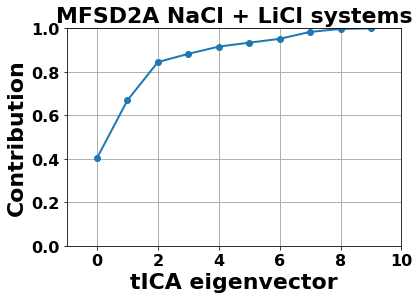

In [22]:
# Make tICA object by fitting to data set I just created 
first_tica = ti.tICA(n_components=None, lag_time=1) # Lag time = always use 10, only when make MSM will matter 
first_tica.fit(first_dataset)

# Making the eigenvector cotribution plot. 
# Check: number of dots == total CV num 
dott = np.dot(first_tica.covariance_,first_tica.eigenvectors_)
trr = 0
for i in range(dott.shape[0]):
    s = np.linalg.norm(dott[:,i])**2
    trr += s

# calculate each eigenvector's contribution
c3 = 0
cont = []
for i in range(dott.shape[0]):
    s = np.linalg.norm(dott[:,i])**2
    c3 += s / float(trr)
    cont.append(c3)

# plot accumulated tICA eigenvector contributions
plt.plot(cont,'o-',lw=2)
plt.xlim([-1,10])	# zooming only on the first 10 tICs
plt.ylim([0,1])
plt.grid(True,lw=1)
plt.xlabel('tICA eigenvector',fontsize=22, fontweight='bold')
plt.ylabel('Contribution',fontsize=22, fontweight='bold')
plt.title('MFSD2A NaCl + LiCl systems',fontsize=22, fontweight='bold')
#plt.savefig('tica_contribution_NaCl_LiCl.pdf', dpi=300)
plt.show()


In [10]:
## Usually want 2-3 eigenvectors to capture > 80% of contributions. 

# Step 3: tiCA/ CV contribution plots 

In [6]:
## need to uncomment/ comment according to tICA eigenvector contribution

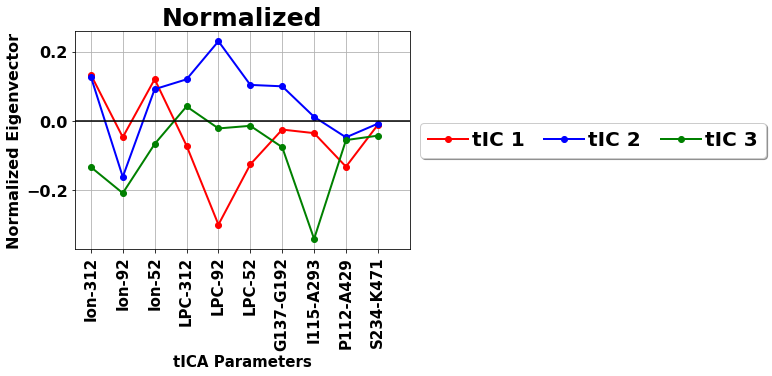

In [15]:
evs=first_tica.eigenvectors_

# naming the parameters so it is not named CV1, etc 
parms = ['Ion-312','Ion-92','Ion-52','LPC-312', 'LPC-92', 'LPC-52', 'G137-G192', 'I115-A293', 'P112-A429', 'S234-K471'] 

# FOR 2 TICs
#plt.figure(figsize=(10,4))
plt.plot(evs[:,0]/float(np.sum(abs(evs[:,0]))),'-ro',linewidth=2)
plt.plot(evs[:,1]/float(np.sum(abs(evs[:,1]))),'-bo',linewidth=2)

#FOR 3 TICs
# If you need more than 2 tiCA vectors then uncomment: 
plt.plot(evs[:,2]/float(np.sum(abs(evs[:,2]))),'-go',linewidth=2)
# FOR 4 TICs
#plt.plot(evs[:,3]/float(np.sum(abs(evs[:,2]))),'-c',linewidth=2)

plt.plot([-0.5,len(parms)],[0,0],'k')
#plt.legend(('tIC 1','tIC 2'),fontsize=22,ncol=3,handletextpad=0.2,shadow=True,fancybox=True,columnspacing=1,labelspacing=0.1,loc='lower right')
plt.legend(('tIC 1','tIC 2'),fontsize=22,ncol=3,handletextpad=0.2,shadow=True,fancybox=True,columnspacing=1,
           labelspacing=0.1,loc='center left', bbox_to_anchor=(1, 0.5))
plt.legend(('tIC 1','tIC 2','tIC 3'),fontsize=20,ncol=3,handletextpad=0.2,shadow=True,fancybox=True,columnspacing=1,
           labelspacing=0.1,loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('Normalized Eigenvector', size=16, fontweight='bold')
plt.xlabel('tICA Parameters',size=15, fontweight='bold')
plt.xlim([-0.5,len(parms)])
plt.grid(True)
plt.title('Normalized',size=25, fontweight='bold')
plt.xticks(range(len(parms)),parms,rotation='vertical',size=15)
#plt.tight_layout()
#plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.2)  
#plt.savefig('contribution_plots.png', dpi=300)
plt.show()


# Step 4: Visualizing tiCA space 

In [16]:
## FOR tIC 1&2

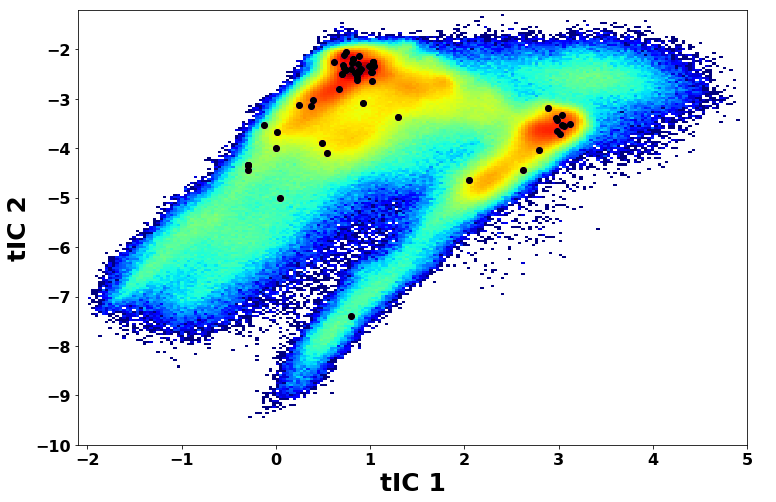

In [15]:
# projecting data onto space 
first_ev0, first_ev1, first_ev2 = [], [], []
for i in range(0,len(first_dataset)): # change to make all combined 
    d = first_dataset[i]
    proj = np.dot(d,first_tica.eigenvectors_)
    first_ev0.extend(proj[:,0])
    first_ev1.extend(proj[:,1])
    first_ev2.extend(proj[:,2])
    
plt.figure(figsize=(12,8))
plt.hist2d(np.array(first_ev0),np.array(first_ev1),bins=200,norm=LogNorm(),cmap=plt.cm.jet)
plt.xlabel('tIC 1',size=25, fontweight='bold')
plt.ylabel('tIC 2',size=25, fontweight='bold')
plt.plot(Li_input_ev0, Li_input_ev1, 'o', color='magenta')
plt.plot(wt_input_ev0, wt_input_ev1, 'o', color='black')
plt.ylim(-10,-1.2)
plt.xlim(-2.1,5)

plt.show()

In [2]:
## EXTRA:
# If you want to visualize specific trajectories on the space 

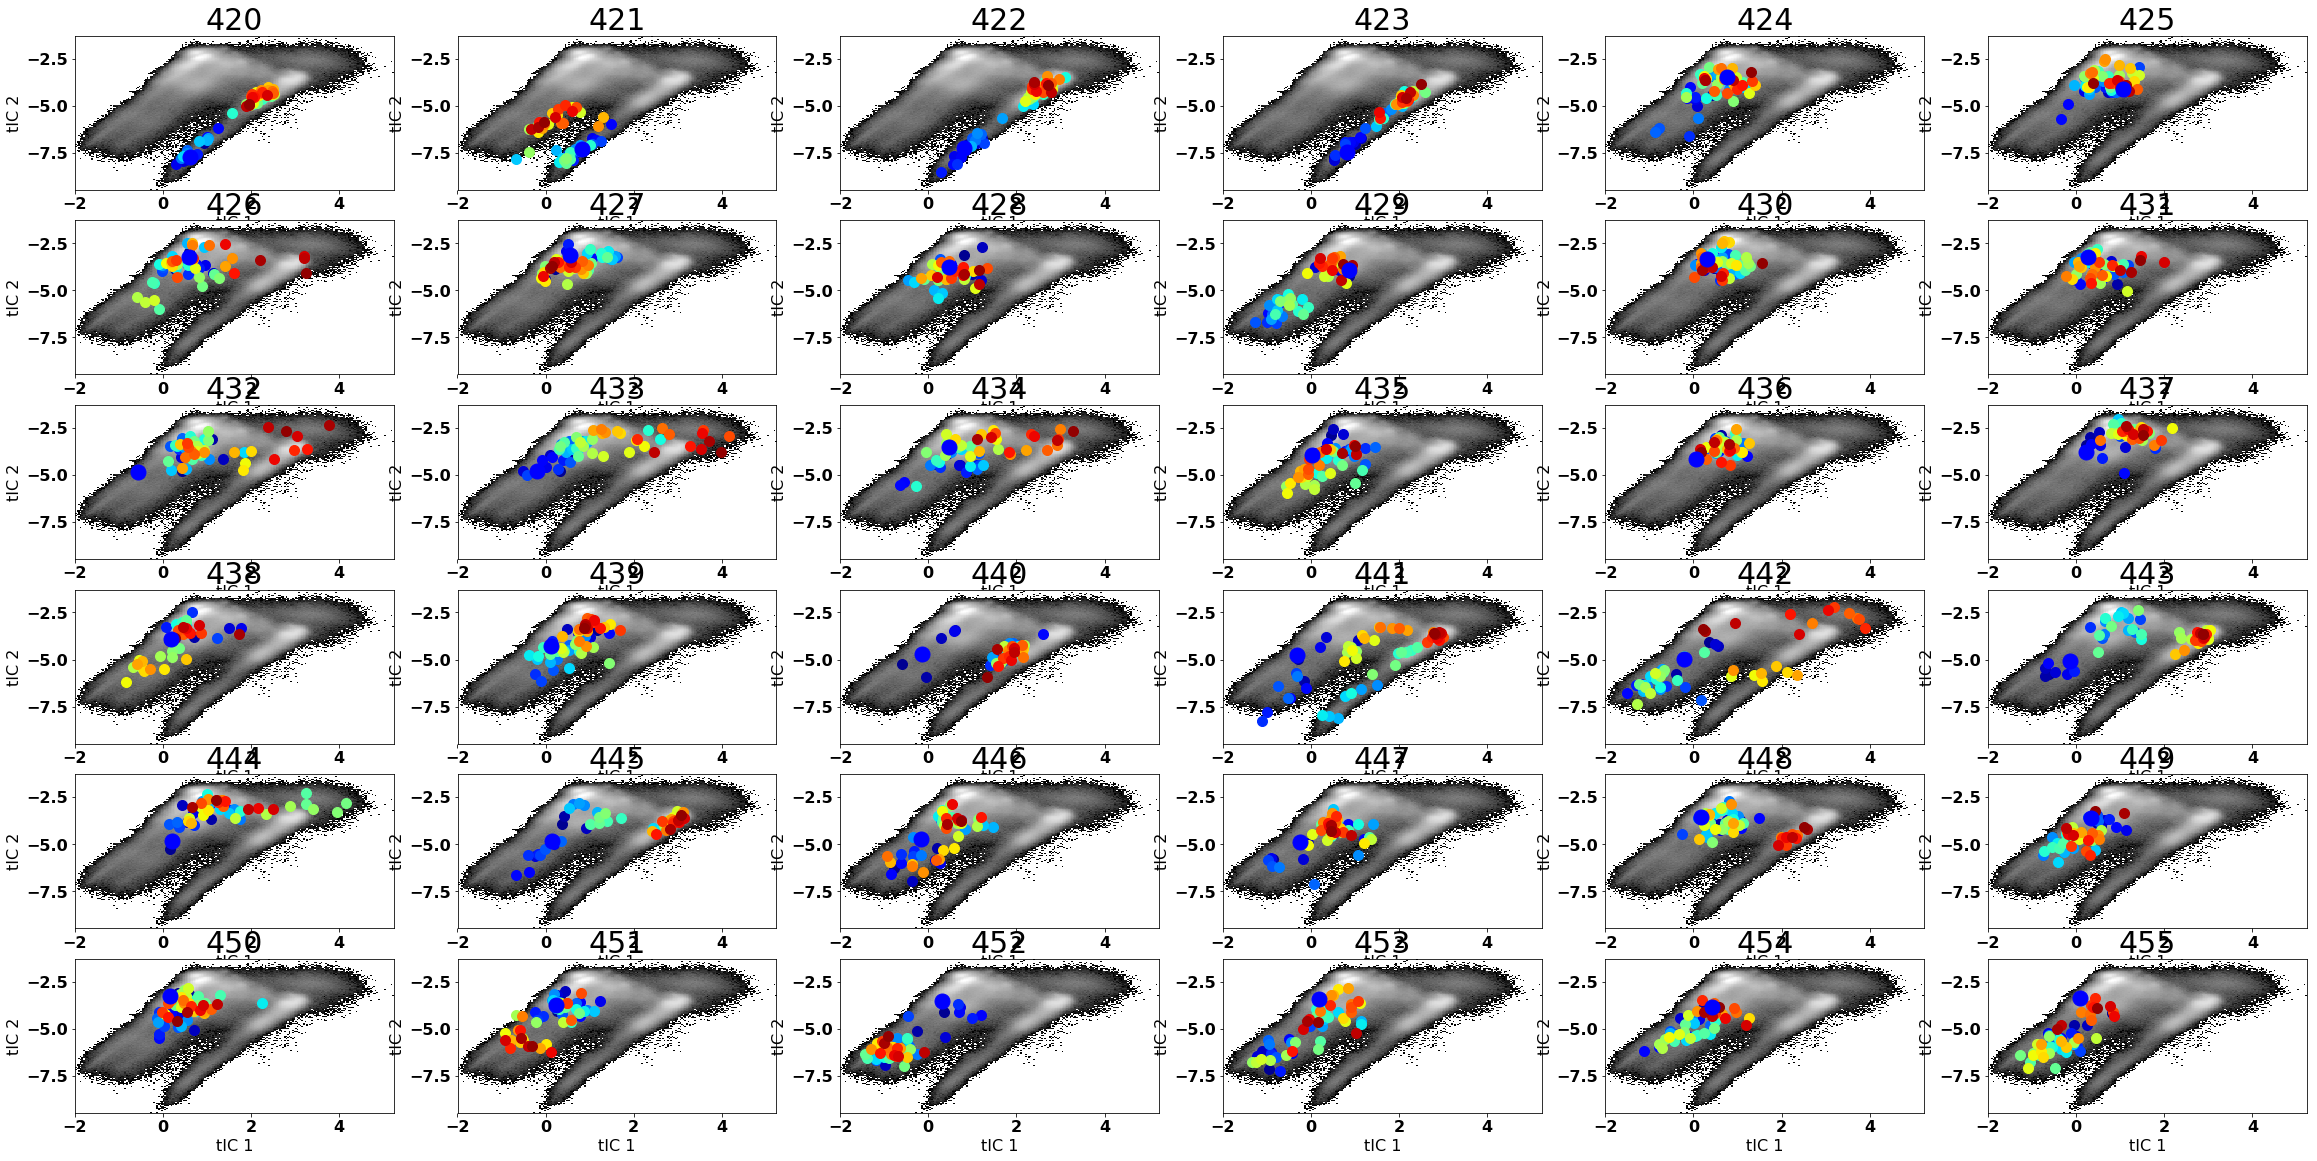

In [56]:
plt.figure(figsize=(40,30))
k=1
for i in range(420, 456): 
    plt.subplot(9,6,k)
    d=first_dataset[i]

    proj=np.dot(d,first_tica.eigenvectors_)
    plt.hist2d(first_ev0,first_ev1,bins=200,norm=LogNorm(),cmap=plt.cm.gray)
    for j in range(proj.shape[0]/50):
        color=cm.jet(float(j)/(proj.shape[0]/50),1)
        plt.plot(np.array(proj[:,0][::50][j]),proj[:,1][::50][j],'o',color=color,markersize=10)
    plt.plot(proj[0,0],proj[0,1],'o',color='blue',markersize=15) # START AT BLUE!!!!!!!  
    plt.xlabel('tIC 1')
    plt.ylabel('tIC 2')
    plt.title(i,size=30)

    k=k+1

# Step 5: Build MSM Prep Microstates 

In [57]:
from msmbuilder.cluster import KMeans, KCenters

In [10]:
# OPTION 1: 2 VECTORS 
# Taking in data and projecting into 2 vectors and saving data 

#_first2_proj=[]
#for traj in range(len(first_dataset)):
#    d=first_dataset[traj]
#    proj=np.dot(d,first_tica.eigenvectors_)
#    df_first2_proj.append(proj[:,0:2][::1]) #striding it by 1 
#    np.save('proj_combined_WT_Li_3d_%d.npy' %traj,proj[:,0:2])


In [58]:
# OPTION 2: 3 VECTORS (3D) 
# Taking in data and projecting into 3 vectors and saving data 

df_first3_proj=[]
 
for traj in range(len(first_dataset)):
    d=first_dataset[traj]
    proj=np.dot(d,first_tica.eigenvectors_)
    df_first3_proj.append(proj[:,0:3][::2]) #striding it by 2
    np.save('proj_combined_WT_Li_CV_3d_%d.npy' %traj,proj[:,0:3]) #fine to re-run

In [38]:
## EXTRA: for MSM:

In [59]:
proj=np.dot(first_dataset[0],first_tica.eigenvectors_)
tics13=pd.DataFrame(proj[:,0:3][::1].tolist()) #striding it by 1 # also change 2 to 3 according to what tiCs using 

for traj in range(1,len(first_dataset)):
    d=first_dataset[traj]
    proj=np.dot(d,first_tica.eigenvectors_)
    tics13=tics13.append(proj[:,0:3][::1].tolist()) #striding it by 1 # also change 2 to 3 according to what tiCs using 

In [ ]:
# Clustering Step: 

In [3]:
### THIS IS WHEN TO DO THE GMRQ! 
### TO KNOW HOW MANY MICROSTATES ARE OPTIMAL FOR YOUR SYSTEM!
### THIS IS SYSTEM DEPENDENT 
### Please look at the GMRQ directory

In [39]:
cluster=KMeans(n_clusters=150,n_jobs=-1,verbose=0,max_iter=100,tol=.0001) #UNCOMMENT
cluster.fit(df_first2_proj) #2 tiC #UNCOMMENT
cluster.fit(df_first3_proj) #3 tiC #UNCOMMENT

KMeans(algorithm='auto', copy_x=True, init='k-means++', max_iter=100,
    n_clusters=150, n_init=10, n_jobs=-1, precompute_distances='auto',
    random_state=None, tol=0.0001, verbose=0)

In [47]:
# WARNING!!! 
# need to uncomment what is commented out rn first time (np.savetxt), and then comment it out again. 
# saving assignment to each cluster. because if not the numbering of the clusters will change 

In [60]:
sequences=[]
for i in range(len(first_dataset)): #UNCOMMENT
    np.savetxt('assigns_150states_stride1_3d_combined_WT_Li_CV_%d.txt' %i,cluster.labels_[i]) #UNCOMMENT 
    np.savetxt('microstate_centers_150states_3d_combined_WT_Li_CV.txt',cluster.cluster_centers_) #UNCOMMENT 
for i in range(len(first_dataset)):
    sequences.extend(np.loadtxt('assigns_150states_stride1_3d_combined_WT_Li_CV_%d.txt' %i)) #save to run MSM, makes 1 large dataframe 
centers=np.loadtxt('microstate_centers_150states_3d_combined_WT_Li_CV.txt')

# Step 5.1: Visualize Microstates and Choose 

In [ ]:
## If 2D comment out 3D, if 3D leave as is

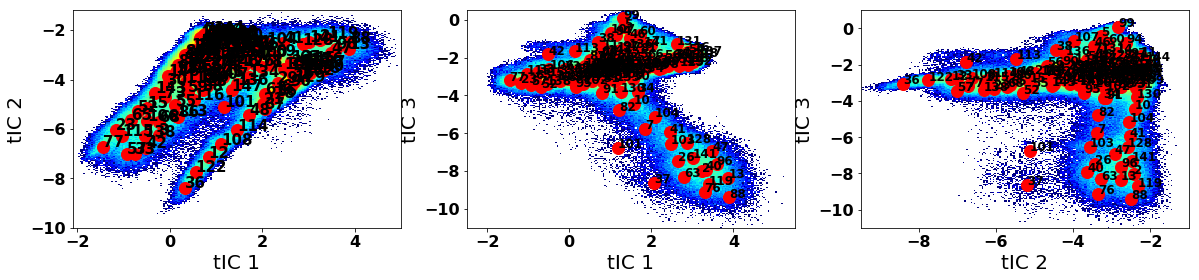

In [61]:
# IF 2D: 
plt.figure(figsize=(20,4))
plt.subplot(1,3,1)
plt.hist2d((first_ev0),first_ev1,bins=200,norm=LogNorm(),cmap=plt.cm.jet)
plt.plot((centers[:,0]),centers[:,1],'ro',markersize=12)
#plt.plot(centers[::50, 0], centers[::50, 1], 'ro', markersize=12)
for i in range(len(centers)):
    #plt.text(centers[i, 0] + 0.1, centers[i, 1] + 0.1, str(i), size=10, color='black', alpha=0.7)
    plt.text((centers[:,0])[i],centers[:,1][i],i,size=15)
    #plt.text(centers[i, 0], centers[i, 1], str(i), size=15)
plt.xlabel('tIC 1',size=20)
plt.ylabel('tIC 2',size=20)
plt.ylim(-10,-1.2)
plt.xlim(-2.1,5)

# IF 3D: 
plt.subplot(1,3,2)
plt.hist2d((first_ev0),first_ev2,bins=200,norm=LogNorm(),cmap=plt.cm.jet)
plt.plot((centers[:,0]),centers[:,2],'ro',markersize=12)
for i in range(len(centers)):
    plt.text((centers[:,0])[i],centers[:,2][i],i,size=12)
plt.xlabel('tIC 1',size=20)
plt.ylabel('tIC 3',size=20)
plt.xlim(-2.5,5.5)
plt.ylim(-11,0.5)
    
plt.subplot(1,3,3)
plt.hist2d((first_ev1),first_ev2,bins=200,norm=LogNorm(),cmap=plt.cm.jet)
plt.plot((centers[:,1]),centers[:,2],'ro',markersize=12)
for i in range(len(centers)):
    plt.text((centers[:,1])[i],centers[:,2][i],i,size=12)
plt.xlabel('tIC 2',size=20)
plt.ylabel('tIC 3',size=20)
plt.xlim(-9.5,-1)
plt.ylim(-11,1)
plt.show()

# Step 6: Histograms for Microstates 

In [38]:
# make dataframe

In [62]:
#make hist of clusters
cluster_hist=np.loadtxt('assigns_150states_stride1_3d_combined_WT_Li_CV_0.txt')

assigns_with_dists=pd.DataFrame(first_dataset[0][::2]) #stride 1
assigns_with_dists.insert(loc=0,column='State',value=cluster_hist.tolist())

In [63]:
#make entire dataframe of all states with their corresponding distances
total_df=assigns_with_dists
for i in range(1,len(first_dataset)):
    trajinfo=np.loadtxt('assigns_150states_stride1_3d_combined_WT_Li_CV_%d.txt' %i)
    assigns_with_dists=pd.DataFrame(first_dataset[i][::2]) #stride 1
    assigns_with_dists.insert(loc=0,column='State',value=trajinfo.tolist())
    total_df=total_df.append(assigns_with_dists)

/ccs/home/margaridarosa/msmbuilder/lib/python2.7/site-packages/matplotlib/figure.py:457: UserWarning: matplotlib is currently using a non-GUI backend, so cannot show the figure
  "matplotlib is currently using a non-GUI backend, "


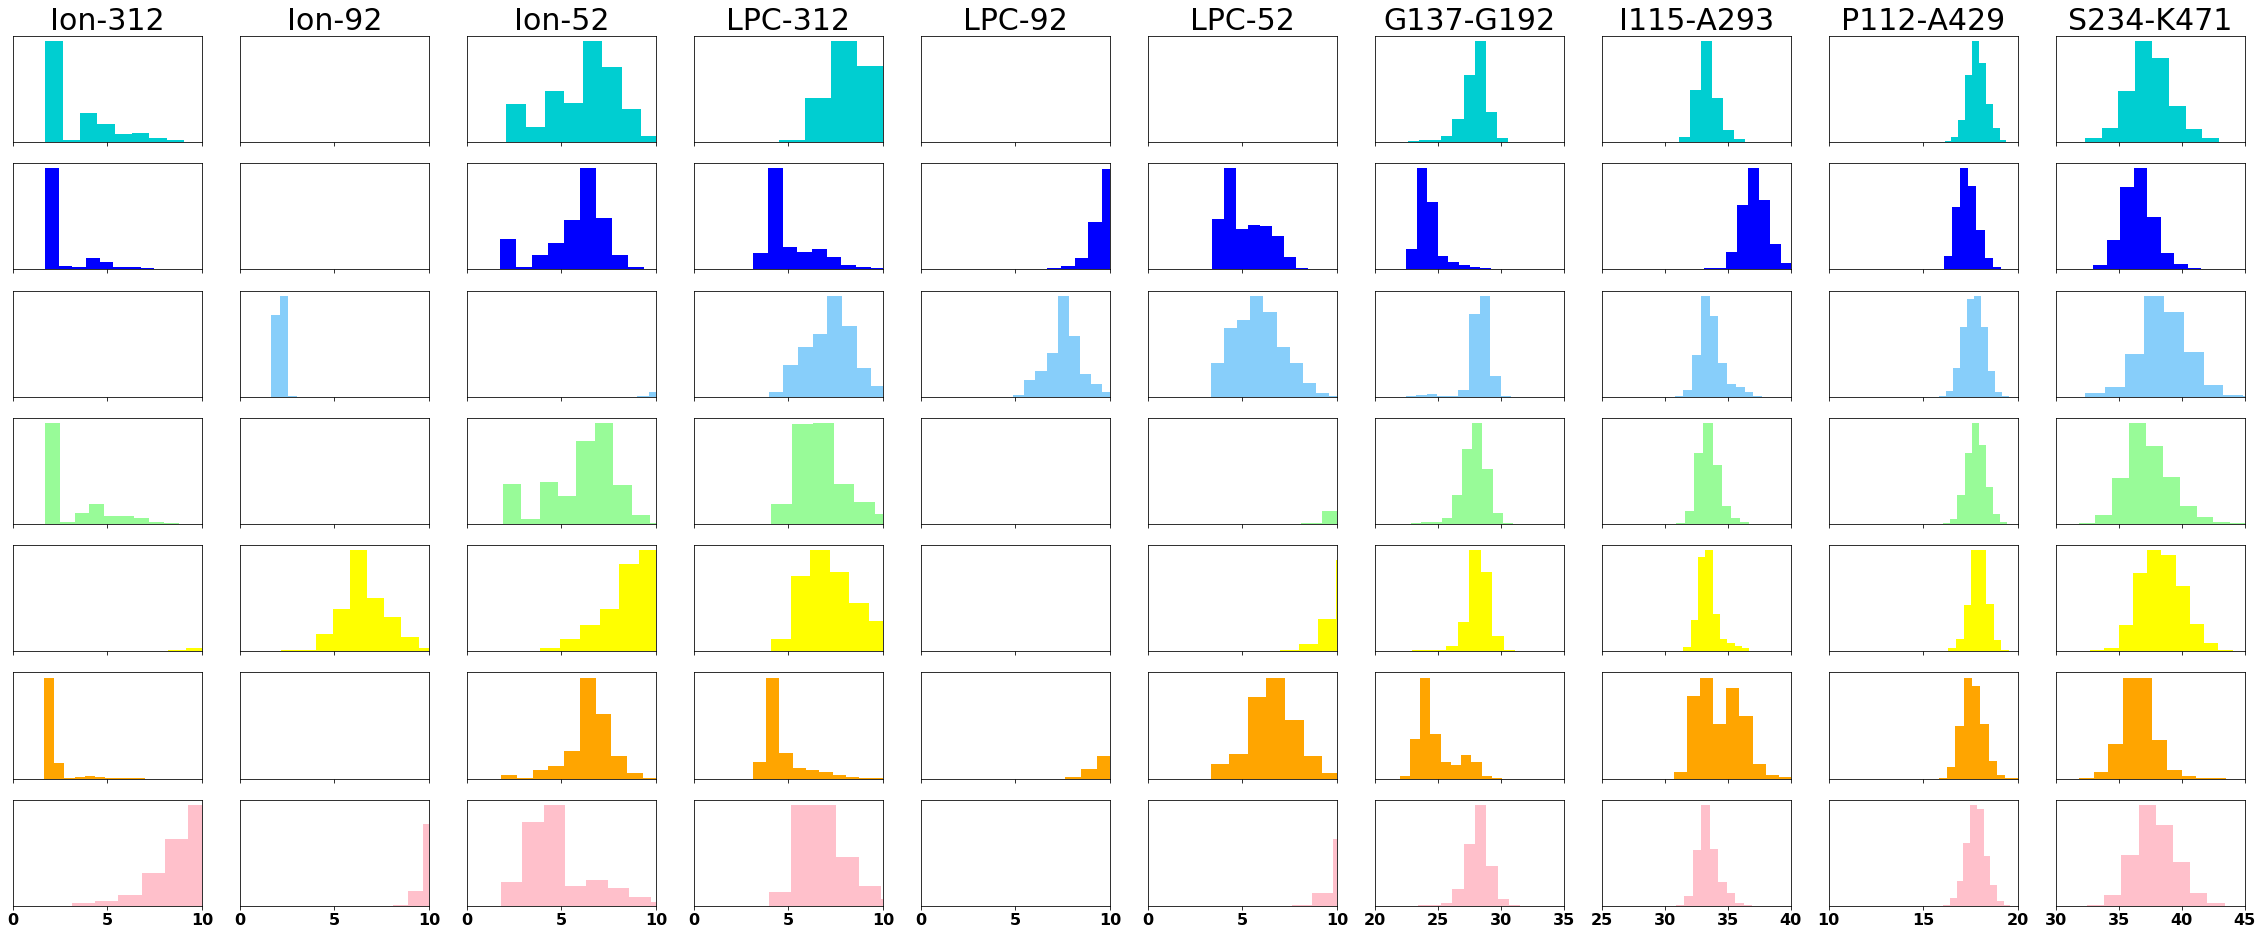

In [87]:
import matplotlib.gridspec as gridspec

fig=plt.figure(figsize=(40,16))

parm_names = ['Ion-312','Ion-92','Ion-52','LPC-312', 'LPC-92', 'LPC-52', 'G137-G192', 'I115-A293', 'P112-A429', 'S234-K471'] 
chosen= [143, 144, 145, 146, 147, 148, 149]
#states we want !!! choosen according to visualization! 

outer=gridspec.GridSpec(1,len(parm_names))
which_range=[(0,10),(0,10),(0,10),(0,10),(0,10), #range of histogram, colored by macrostate and histogram in the middle 
             (0,10), (20,35), (25,40), (10,20), (30,45)]
colors=['darkturquoise', 'blue', 'lightskyblue', 'palegreen', 'yellow', 'orange', 'pink','red', 'purple', 'lightcoral', 'magenta', 'lightyellow', 'lightcyan', 'lightpink', 'lightgreen', 'blue', 'black', 'darkgreen']
for i in range(len(parm_names)):
    inner=gridspec.GridSpecFromSubplotSpec(len(chosen),1,subplot_spec=outer[i])
    
    for k in range(len(chosen)):
        ax=plt.Subplot(fig,inner[k])
        ax.hist((total_df.loc[total_df['State']==float(chosen[k])][i].tolist()),color=colors[k],density=True)
        ax.set_xlim(which_range[i])
        ax.set_yticks([])
        if k==0:
            ax.set_title(parm_names[i],fontsize=30)
        if k!=(len(chosen)-1):
            ax.set_xticklabels([])
                                           
        # Increase x-axis label font size
        ax.tick_params(axis='x', labelsize=16)  # Adjust as needed for visibility
            
        fig.add_subplot(ax)

#plt.savefig('histograms_NaCl_LiCl.pdf', dpi=300)
fig.show()

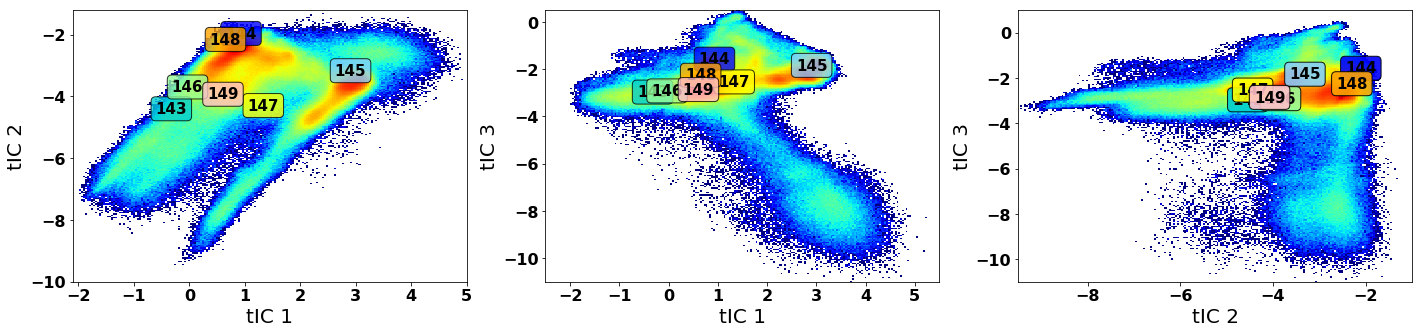

In [86]:
chosen= [143, 144, 145, 146, 147, 148, 149]

colors=['darkturquoise', 'blue', 'lightskyblue', 'palegreen', 'yellow', 'orange', 'pink','red', 'purple', 'lightcoral', 'magenta', 'lightyellow', 'lightcyan', 'lightpink', 'lightgreen', 'blue', 'black', 'darkgreen']
plt.figure(figsize=(24,5))
plt.subplot(1,3,1)
plt.hist2d(np.array(first_ev0),first_ev1,bins=200,norm=LogNorm(),cmap=plt.cm.jet)
for i in range(len(chosen)):
    plt.text(np.array(centers[chosen[i],0]),centers[chosen[i],1],chosen[i],size=15,ha="center",bbox=dict(boxstyle='round',fc=colors[i],ec='k',alpha=.8))
plt.xlabel('tIC 1',fontsize=20)
plt.ylabel('tIC 2',fontsize=20)
plt.ylim(-10,-1.2)
plt.xlim(-2.1,5)

plt.subplot(1,3,2)
plt.hist2d(first_ev0,first_ev2,bins=200,norm=LogNorm(),cmap=plt.cm.jet)
#plt.plot(np.array(centers[:,0]),centers[:,2],'ro',markersize=12)
for i in range(len(chosen)):
    plt.text(np.array(centers[chosen[i],0]),centers[chosen[i],2],chosen[i],size=15,ha="center",bbox=dict(boxstyle='round',fc=colors[i],ec='k',alpha=.8))
plt.xlabel('tIC 1',fontsize=20)
plt.ylabel('tIC 3',fontsize=20)
plt.xlim(-2.5,5.5)
plt.ylim(-11,0.5)

plt.subplot(1,3,3)
plt.hist2d(first_ev1,first_ev2,bins=200,norm=LogNorm(),cmap=plt.cm.jet)
for i in range(len(chosen)):
    plt.text(centers[chosen[i],1],centers[chosen[i],2],chosen[i],size=15,ha="center",bbox=dict(boxstyle='round',fc=colors[i],ec='k',alpha=.9))
plt.xlabel('tIC 2',fontsize=20)
plt.ylabel('tIC 3',fontsize=20)
plt.xlim(-9.5,-1)
plt.ylim(-11,1)
plt.show()

# Step 7: Implied Lag time Plot 

In [25]:
lag_times = [5,50,100]+range(100,7000,500) #Play with range 
n_timescales = len(lag_times)
msm_timescales_d = implied_timescales(sequences, lag_times, n_timescales=n_timescales, n_jobs=1, \
                                      msm=MarkovStateModel(verbose=True,  reversible_type='transpose',ergodic_cutoff=0),verbose=1)


[Parallel(n_jobs=1)]: Done  17 out of  17 | elapsed:   12.4s finished


Text(0.5,1,'MFSD2A: WT + Li Systems')

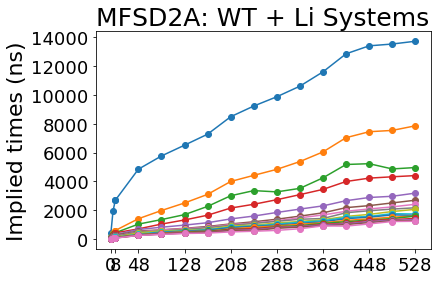

In [26]:
for i in range(n_timescales):
    plt.plot(lag_times,msm_timescales_d[:,i],'o',linestyle='solid')
#plt.semilogy()
#plt.xticks([5,15,30,50,100,300,500,700,900],np.array([5,15,30,50,100]+range(100,1000,200))*80000/1000000,fontsize=18)
plt.xticks(lag_times[::2],np.array(lag_times[::2])*80000/1000000,fontsize=18) # converting from frame to ns 

plt.yticks(fontsize=18)
#plt.xlabel('Lag times (ns)',fontsize=22)
plt.ylabel('Implied times (ns)',fontsize=22)
plt.title('MFSD2A: WT + Li Systems',fontsize=25)

# Step 8: Build MSMs using Macrostates 

In [ ]:
# From implied timescale plot use lag time (eg. 128 where it converges) and update in the next cell
# Use microstate to get transitions and build macro for MSM

In [27]:
micro_msm = MarkovStateModel(lag_time=448, n_timescales=20, reversible_type='transpose', ergodic_cutoff='off', prior_counts=0, sliding_window=True, verbose=True)
micro_msm.fit(sequences)

MarkovStateModel(ergodic_cutoff='off', lag_time=448, n_timescales=20,
         prior_counts=0, reversible_type='transpose', sliding_window=True,
         verbose=True)

In [ ]:
# Choose # of macrostates

In [29]:
import msmbuilder.lumping as lump
m = lump.PCCAPlus.from_msm(micro_msm,n_macrostates=10)

Optimization terminated successfully.
         Current function value: -5.239407
         Iterations: 8
         Function evaluations: 663


In [31]:
map15_pccaplus=m.microstate_mapping_

In [32]:
# tells you mapping of microsrate to macro states 

In [33]:
def mapp(micro_assigns,macro_map):
    n_macros = int(np.max(macro_map)) + 1
    macro_assigns = np.ones(len(micro_assigns))  * -100
    for i in range(n_macros):
        ind_map = np.where(macro_map == i)[0]
        for m in ind_map:
            ind = (micro_assigns == m)
            macro_assigns[ind] = i
    if [-100] in macro_assigns:
        print "not all micro assignments are converted"
    return macro_assigns 

In [34]:
micro_assigns=sequences #assignment of every frame to microstate 
macro_assigns=mapp(micro_assigns,map15_pccaplus) #assigns each frame to macrostate 

In [ ]:
# This output is which microstate is in each macrostate
# for all 30 microstates, to which macrostate it is being assigned to. 
# for example the first one, microstate is 0, is in macrostate 4 (in order 0,1,2,etc), microstate 1 is in macrostate 6 
# this is center, we want to also konw where each frame is

In [35]:
map15_pccaplus

array([3, 6, 8, 1, 9, 5, 7, 4, 2, 5, 6, 4, 7, 0, 6, 3, 5, 9, 5, 6, 5, 1, 8,
       5, 2, 3, 4, 7, 3, 9])

# Step 9: Build MSM from frames 

In [ ]:
# for visualization, takes centers (x,y) of macrostates and makes figure below 
# circles are the centers 

In [36]:
circls = []
r1, r2 = 0.2 , 0.2
for i in range(15):
    ind = [map15_pccaplus == i]
    avg_x=np.average(centers[:,0][ind])
    avg_y=np.average(centers[:,1][ind])
    circls.append([avg_x,avg_y,r1,r2])

In [ ]:
## 2D 

Text(0.5,1,'MFSD2A: WT + Li Systems')

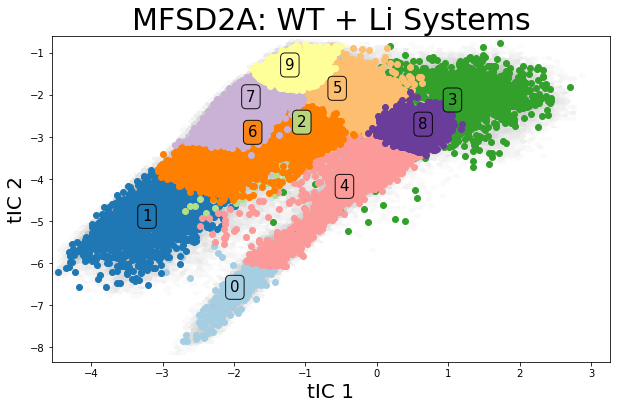

In [39]:
map15 = map15_pccaplus #which macrostates the centers are assigned to
assigns = macro_assigns #assignment of each frame  of each  trajectory
gens = centers

plt.figure(figsize=(10,6))
plt.hexbin(first_ev0[::1], first_ev1[::1], bins='log', mincnt=1, cmap="Greys")

#plt center of macrostates, colored by their macrostate
for i in range(10): #for all 7 macrostates
    c = cm.Paired(i/10.,1) #for all 7 macrostates, colors according to macrostate
    ind = [map15 == i]
    plt.plot(gens[:,0][ind],gens[:,1][ind],'o',c=c,linewidth=0)#colors[i])

    #frame_ind = [macro_assigns==i]
    plt.plot(tics13[0][macro_assigns==i][::50], tics13[1][macro_assigns==i][::50], 'o',color=c)
    plt.text(circls[i][0],circls[i][1],s=i,size=15,ha="center",bbox=dict(boxstyle='round',fc=c,ec='k',alpha=.9))

    #plt.text(gens[i,0],gens[i,1],s=i,size=30)
#plt.legend(range(15),ncol=5,labelspacing=0.2,numpoints=1,handletextpad=0.01,handlelength=1.5,columnspacing=0.2,shadow=True,fancybox=True,fontsize=16,bbox_to_anchor=(0.85,1.1))
plt.xlabel('tIC 1',size=20)
plt.ylabel('tIC 2',size=20)
plt.title('MFSD2A: WT + Li Systems',size=30)

In [ ]:
### This looks really bad, because we grouped in 3D and visualized in 2D 

## Step 10: 3D

Text(0.5,0,'tIC 3')

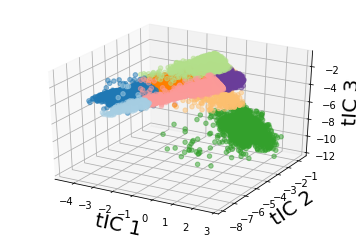

In [40]:
map15 = map15_pccaplus #which macrostates the centers are assigned to
assigns = macro_assigns #assignment of each frame  of each  trajectory
gens = centers

ax=plt.axes(projection='3d') 
#ax.scatter3D(first_ev0[::50],first_ev1[::50],first_ev2[::50],marker='o',color='grey', alpha=0.5) #transparency 0.5 stride 50 
#ax.scatter3D(centers[:,0],centers[:,1],centers[:,2],marker='o',color='red') #centers are microstates 

#plt center of macrostates, colored by their macrostate
for i in range(10): #for all 7 macrostates
    c = cm.Paired(i/10.,1) #for all 7 macrostates, colors according to macrostate
    ind = [map15 == i]
    #plt.plot(gens[:,0][ind],gens[:,1][ind],'o',c=c,linewidth=0)#colors[i])

    #frame_ind = [macro_assigns==i]
    ax.scatter3D(tics13[0][macro_assigns==i][::50], tics13[1][macro_assigns==i][::50],tics13[2][macro_assigns==i][::50], 'o',color=c,alpha=.5)
   # plt.text(circls[i][0],circls[i][1],s=i,size=15,ha="center",bbox=dict(boxstyle='round',fc=c,ec='k',alpha=.9))

    #plt.text(gens[i,0],gens[i,1],s=i,size=30)
#plt.legend(range(15),ncol=5,labelspacing=0.2,numpoints=1,handletextpad=0.01,handlelength=1.5,columnspacing=0.2,shadow=True,fancybox=True,fontsize=16,bbox_to_anchor=(0.85,1.1))
plt.xlabel('tIC 1',size=20)
plt.ylabel('tIC 2',size=20)
ax.set_zlabel('tIC 3',size=20)
#plt.title('MFSD2A WT',size=30)

In [ ]:
## Make it prettier: adjust azim according and alpha  

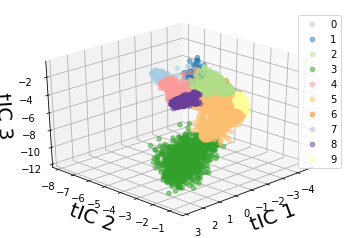

In [43]:
ax=plt.axes(projection='3d') 
for i in range(10): #for all 7 macrostates
    c = cm.Paired(i/10.,1) #for all 7 macrostates, colors according to macrostate
    ind = [map15 == i]
    ax.scatter3D(tics13[0][macro_assigns==i][::50], tics13[1][macro_assigns==i][::50],tics13[2][macro_assigns==i][::50], 'o',color=c,alpha=.5)
    ax.view_init(azim=45)
    plt.xlabel('tIC 1',size=20)
    plt.ylabel('tIC 2',size=20)
    ax.set_zlabel('tIC 3',size=20)
ax.legend(range(10))

# Step 11: Visualize the CVs for each of the macrostates 

/ccs/home/margaridarosa/msmbuilder/lib/python2.7/site-packages/matplotlib/figure.py:457: UserWarning: matplotlib is currently using a non-GUI backend, so cannot show the figure
  "matplotlib is currently using a non-GUI backend, "


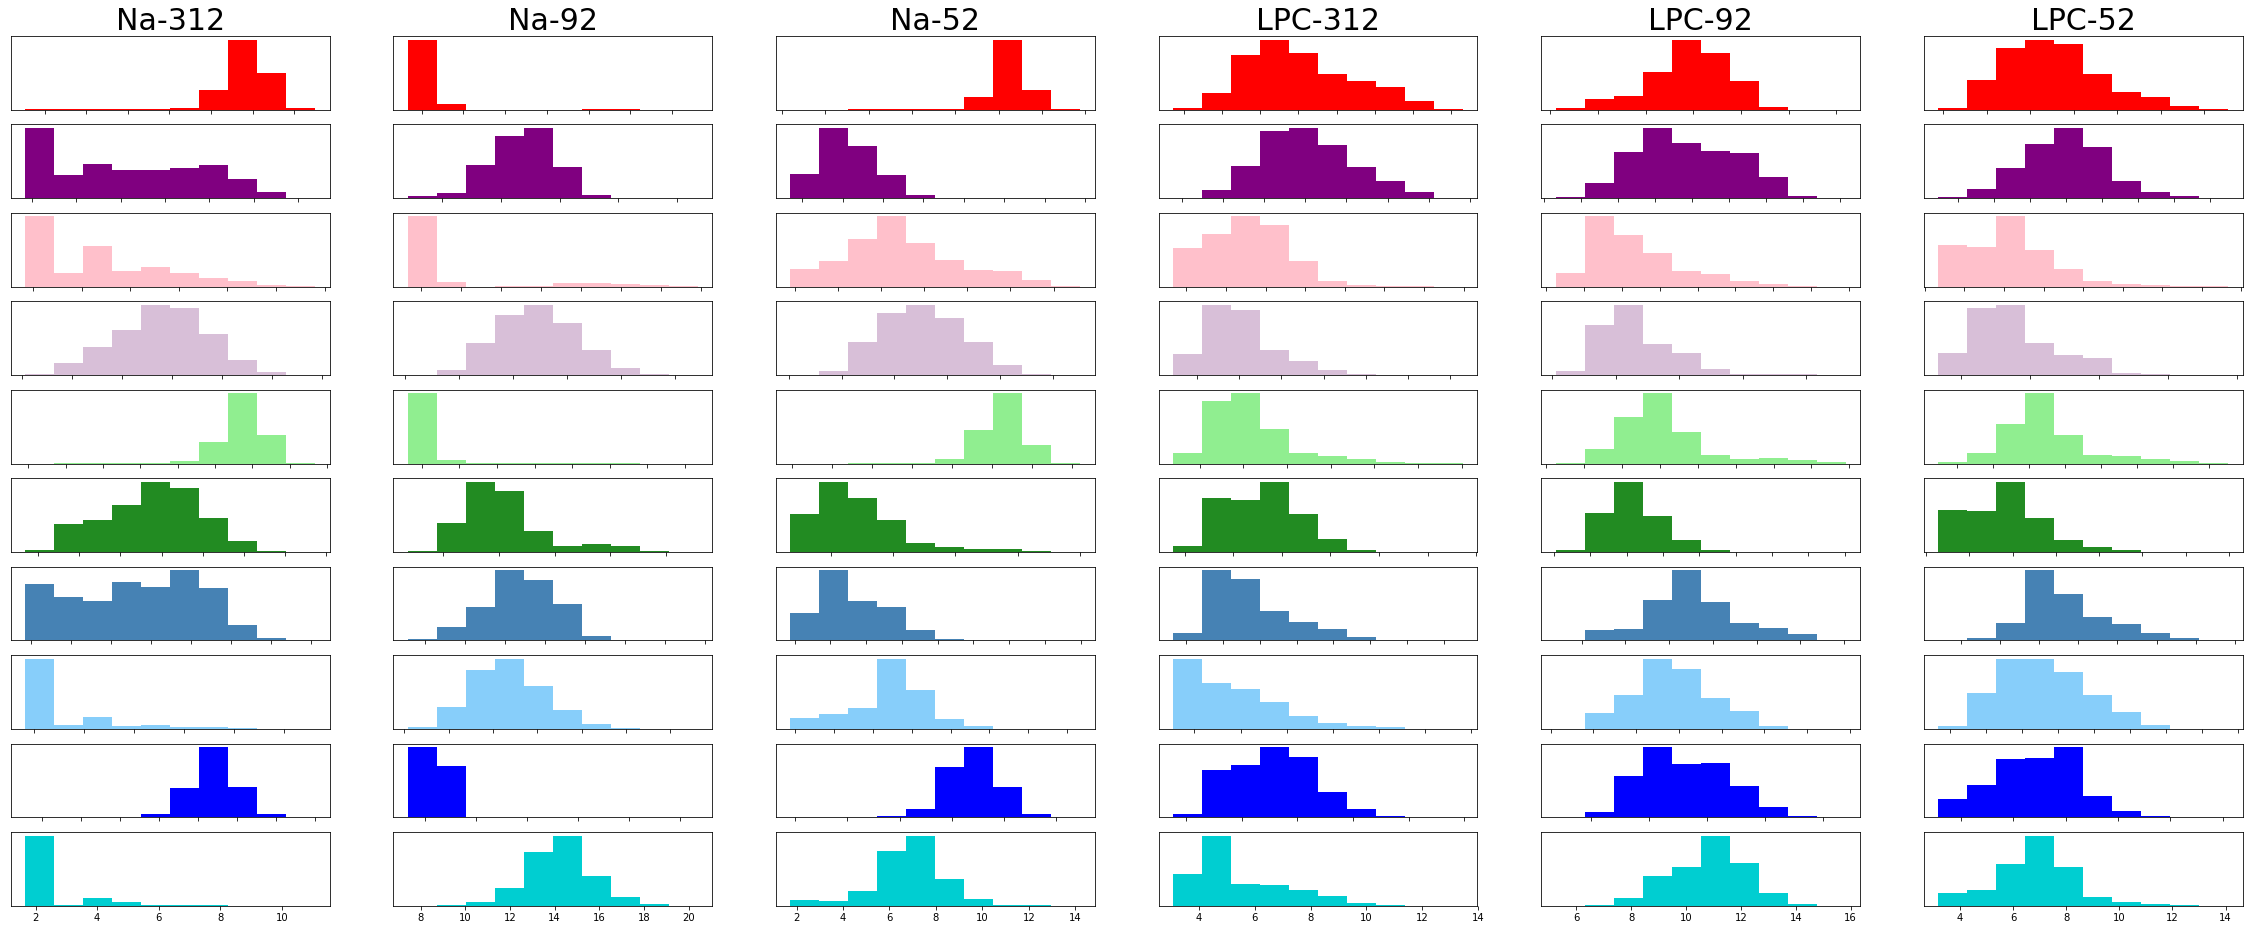

In [42]:
import matplotlib.gridspec as gridspec

fig=plt.figure(figsize=(40,16))
parm_names=['Na-312','Na-92','Na-52','LPC-312', 'LPC-92', 'LPC-52']

chosen=[0,1, 2, 3, 4, 5, 6, 7, 8, 9] # MACROSTATES 
outer=gridspec.GridSpec(1,len(parm_names))
which_range=[(0,10),(0,10),(0,10),(0,10),(0,10), #range of histogram, colored by macrostate and histogram in the middle 
             (0,10), (0,10), (0,10), (0,10), (0,10), (0,10)]

colors=['red','purple', 'pink','thistle','lightgreen','forestgreen','steelblue','lightskyblue', 'blue','darkturquoise', 'lightskyblue'] ## Change according to colors used in Macrostates 
for i in range(len(parm_names)):
    inner=gridspec.GridSpecFromSubplotSpec(len(chosen),1,subplot_spec=outer[i])
    
    for k in range(len(chosen)):
        ax=plt.Subplot(fig,inner[k])
        ax.hist(total_df[macro_assigns==k][i].tolist(),color=colors[k],density=True)
        #ax.set_xlim(which_range[i])
        ax.set_yticks([])
        if k==0:
            ax.set_title(parm_names[i],fontsize=30)
        if k!=(len(chosen)-1):
            ax.set_xticklabels([])
        fig.add_subplot(ax)

fig.show()

# Step 12: Transition Pathways 

In [ ]:
# Assigned all frames to macrostates, so will make MSM of macrostates now 

In [ ]:
# Here the lag time will matter, so it should be Markovian !!!! 

In [119]:
macro_assigns=mapp(micro_assigns,map15_pccaplus)
macro_msm = MarkovStateModel(lag_time=128, n_timescales=20, reversible_type='transpose', ergodic_cutoff='off', prior_counts=0, sliding_window=True, verbose=True)	
macro_msm.fit(macro_assigns)

MarkovStateModel(ergodic_cutoff='off', lag_time=128, n_timescales=20,
         prior_counts=0, reversible_type='transpose', sliding_window=True,
         verbose=True)

In [123]:
import msmbuilder.tpt as tpt

sources = [5,6] #macrostate where we think it starts 
sinks = [0,1,3] #where it 'ends'
net_flux = tpt.net_fluxes(sources, sinks, macro_msm, for_committors=None)
pfold = tpt.committors(sources, sinks, macro_msm)
paths = tpt.paths(sources, sinks, net_flux, remove_path='subtract', flux_cutoff=0.9999999999)
total_flux = np.sum(paths[1])
data = []
acuu_f = 0
for j in range(len(paths[1])):
    acuu_f += paths[1][j]/float(total_flux)
    data.append([paths[0][j],((paths[1][j]/float(total_flux))).round(4),acuu_f])
df=pd.DataFrame(data,columns=['Path','Norm Flux','Accumulated Flux'])
    

In [124]:
df

,Path,Norm Flux,Accumulated Flux
0,"[5, 4, 3]",0.4173,0.417292
1,"[5, 1]",0.3435,0.760824
2,"[6, 0]",0.1024,0.863212
3,"[5, 4, 1]",0.0495,0.912727
4,"[6, 4, 1]",0.0293,0.942010
5,"[5, 3]",0.0286,0.970591
6,"[6, 3]",0.0125,0.983134
7,"[6, 2, 3]",0.0071,0.990210
8,"[6, 2, 4, 0]",0.0043,0.994468
9,"[5, 2, 0]",0.0025,0.997001


In [ ]:
## Visualize in the MSMs and add arrows accordingly 
## where arrow sizes are porportional to biggest (norm flux) flux in this case 543
## also probably only want to only show first 4 (0-3) because we are ~90% of accumulated flux 